# Convolutional Neural Nets - CIFAR-10



https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html




In [ ]:
import torchvision # provides computer vision functionalities and utilities built on top of PyTorch.
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Set the random seed
torch.manual_seed(42)



## Transforms

More reading here:

https://pytorch.org/vision/stable/transforms.html


In [ ]:
classes = ['plans', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


train_transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


### Data Loaders

Read more here:

https://towardsdatascience.com/beginners-guide-to-loading-image-data-with-pytorch-289c60b7afec and then https://stackoverflow.com/questions/51756581/how-do-i-turn-a-pytorch-dataloader-into-a-numpy-array-to-display-image-data-with

https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

## Download the data

1. Download data and use transforms.
2. Split into train and test.
3. Make data loaders for training and testing

In [ ]:
datasets.CIFAR10.url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"


In [ ]:
# download and load training data
train_dataset = datasets.CIFAR10(root='./data', train=True,
                                 download=True, transform=train_transform)

# download and load test data
test_dataset = datasets.CIFAR10(root='./data', train=False,
                                download=True, transform=train_transform)

100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


In [ ]:
# data loaders

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### How many data points do we have?

In [ ]:
print(len(train_dataset))
print(len(test_dataset))

50000
10000


## Image Visualization



frog


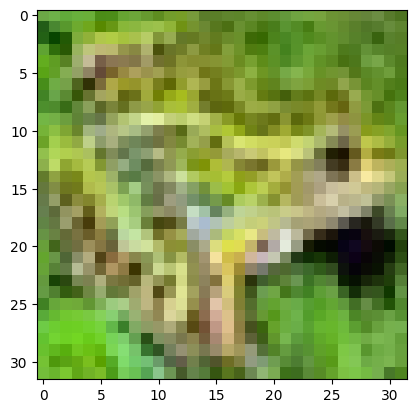

In [ ]:
# Displaying an image from the Dataloader.
# The commands below pick a random element from the data set to display.
# See https://towardsdatascience.com/beginners-guide-to-loading-image-data-with-pytorch-289c60b7afec
# and then https://stackoverflow.com/questions/51756581/how-do-i-turn-a-pytorch-dataloader-into-a-numpy-array-to-display-image-data-with


import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
%matplotlib inline

dataiter = iter(train_loader)
images, lables = next(dataiter)
images = images / 2 + 0.5     # unnormalize
plt.imshow(np.transpose(images[0].numpy(), (1, 2, 0)))
print(classes[lables[0]])

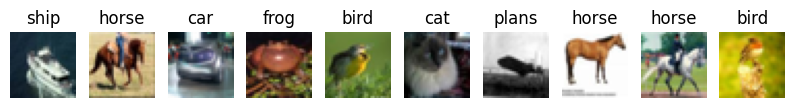

In [ ]:
import matplotlib.pyplot as plt

def show_images(dataloader, classes, k=5):
    """
    Displays k images from the provided DataLoader with their corresponding labels.

    Args:
    dataloader (torch.utils.data.DataLoader): The DataLoader to sample images from.
    classes (list): List of class names corresponding to label indices.
    k (int): Number of images to display.
    """
    # Create an iterator from the dataloader
    dataiter = iter(dataloader)
    images, labels = next(dataiter)  # Use next() to get one batch of images and labels

    plt.figure(figsize=(10, 2 * k))
    for idx in range(min(k, len(images))):  # Ensure we do not go out of bounds
        ax = plt.subplot(1, k, idx + 1)
        img = images[idx].numpy().transpose((1, 2, 0))  # Convert from PyTorch tensor to NumPy array and transpose
        img = (img - img.min()) / (img.max() - img.min())  # Normalize to [0, 1] for visualization

        plt.imshow(img)
        plt.title(classes[labels[idx]])
        plt.axis('off')
    plt.show()

show_images(train_loader, classes, k=10)


## Model Implementation.

We build our CNN using:

* Convolutional layers: `nn.Conv2d`
* Max Pooling layers:`nn.MaxPool2d`
* Average Pooling layers: `nn.AvgPool2d`
* Fully Connected layers: `nn.Linear`
* ReLU layers: `nn.ReLU`


https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html


## First CNN

Some details:
```
nn.Conv2d(3,16,7, 2, 3)
```
What do these numbers mean?

What is the output size?

The layer
```
x = x.mean(dim=(2,3))
```
looks separately at each of the 16 channels, and replaces their 16 x 16 values with their average. This is called: Average Pooling.

What is the output size?

In [ ]:
class CNNClassifier1(torch.nn.Module):
    def __init__(self):
        """
        Define the layer(s) needed for the model.
        Feel free to define additional input arguments.
        """
        super().__init__()
        self.conv = nn.Conv2d(3, 16, 7, 2, 3)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(16, 10)


    def forward(self, x):
        """
        Define the forward pass of the model.
        """
        # Add convolutional layer
        x = self.conv(x)
        # Add a ReLU
        x = self.relu(x)
        # Add global average pooling
        x = x.mean(dim=(2,3))
        return self.fc(x) # Note: we do not need a softmax if using CrossEntropyLoss (see optimization function)

    def predict(self, image):
        return self(image).argmax(1)


In [ ]:
# How many trainable parameters?
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Model Training and Validation


In [ ]:
# Use a GPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
device

device(type='cuda', index=0)

### Optimization


In [ ]:
from torch import optim

import torch
import copy
import torch.nn.functional as F
import matplotlib.pyplot as plt

def train(model, train_loader, test_loader, optimizer, epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # criterion
    criterion = torch.nn.CrossEntropyLoss() # use nn.nLLLoss() if your model has a log_softmax

    # scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)


    train_losses = []
    test_losses = []
    test_accuracies = []  # List to store accuracy for each epoch
    best_accuracy = 0  # Best accuracy found
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()  # Update the learning rate

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        total_test_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_test_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_loss = total_test_loss / len(test_loader)
        epoch_accuracy = correct / total
        test_losses.append(epoch_loss)
        test_accuracies.append(epoch_accuracy)

        if epoch_accuracy > best_accuracy:
            best_accuracy = epoch_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {train_losses[-1]}, Testing Loss: {test_losses[-1]}, Testing Accuracy: {epoch_accuracy:.4f}")

    # Load best model weights
    model.load_state_dict(best_model_wts)
    print(f"Loaded the best model from epoch {best_epoch} with Testing Accuracy: {best_accuracy:.4f}")

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
    plt.plot(range(1, epochs+1), test_losses, label='Testing Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs+1), test_accuracies, label='Testing Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

    return # train_losses, test_losses, test_accuracies, best_accuracy

In [ ]:
def evaluate(model, data_loader, device):
    model.eval()  # Set model to evaluate mode
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

## Time to Train

Epoch 1/5, Training Loss: 2.217347634425929, Testing Loss: 2.1343720328693574, Testing Accuracy: 0.2278
Epoch 2/5, Training Loss: 2.1042145844537026, Testing Loss: 2.0661746217800787, Testing Accuracy: 0.2430
Epoch 3/5, Training Loss: 2.0564177723473946, Testing Loss: 2.030694032629458, Testing Accuracy: 0.2601
Epoch 4/5, Training Loss: 2.026406919506217, Testing Loss: 2.0046857858237366, Testing Accuracy: 0.2665
Epoch 5/5, Training Loss: 2.001881193290974, Testing Loss: 1.9800401865102994, Testing Accuracy: 0.2760
Loaded the best model from epoch 5 with Testing Accuracy: 0.2760


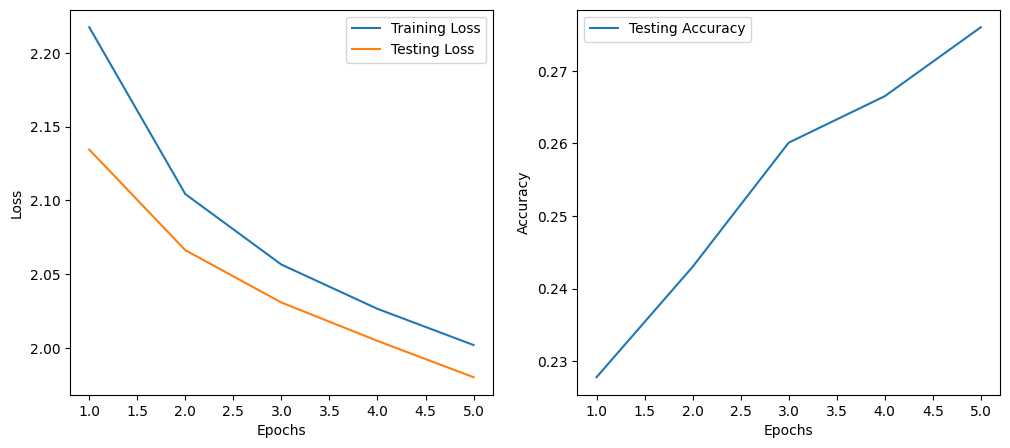

In [ ]:
torch.manual_seed(42)

model = CNNClassifier1()

# optimization
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# epochs
epochs = 5
train(model, train_loader, test_loader, optimizer, epochs)



### What should we do now?


**NB**: what happens if we give the command ``model = CNNClassifier1()`` ?

Epoch 1/5, Training Loss: 1.979018433614183, Testing Loss: 1.9578278434162322, Testing Accuracy: 0.2925
Epoch 2/5, Training Loss: 1.9565171605108338, Testing Loss: 1.935233040739553, Testing Accuracy: 0.3027
Epoch 3/5, Training Loss: 1.934792577648346, Testing Loss: 1.913996702946794, Testing Accuracy: 0.3121
Epoch 4/5, Training Loss: 1.9139010672834693, Testing Loss: 1.893535152791788, Testing Accuracy: 0.3179
Epoch 5/5, Training Loss: 1.895039794922485, Testing Loss: 1.8763317898058662, Testing Accuracy: 0.3215
Loaded the best model from epoch 5 with Testing Accuracy: 0.3215


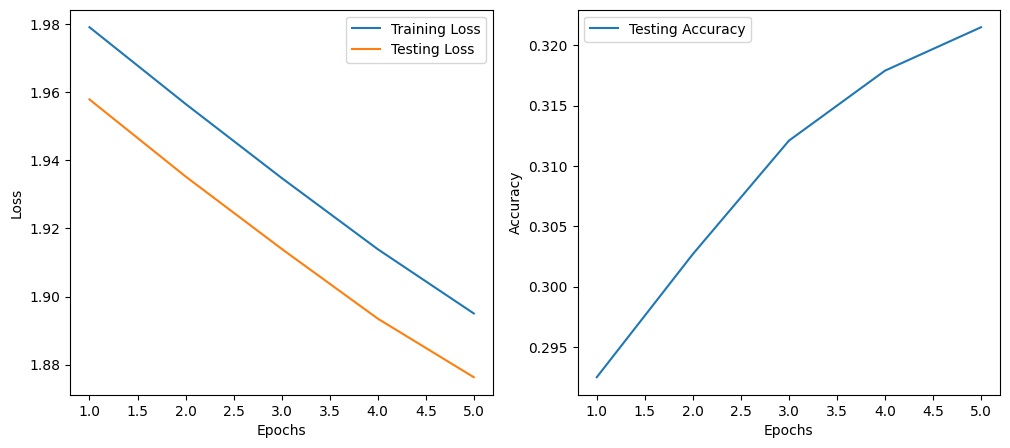

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
epochs = 5
train(model, train_loader, test_loader, optimizer, epochs)

## Keep going..!


Epoch 1/5, Training Loss: 1.878055717879507, Testing Loss: 1.8601528200478599, Testing Accuracy: 0.3245
Epoch 2/5, Training Loss: 1.862852512226605, Testing Loss: 1.8456497489453885, Testing Accuracy: 0.3283
Epoch 3/5, Training Loss: 1.849576729883083, Testing Loss: 1.8334725063068036, Testing Accuracy: 0.3323
Epoch 4/5, Training Loss: 1.8377297614830392, Testing Loss: 1.8223728520420794, Testing Accuracy: 0.3371
Epoch 5/5, Training Loss: 1.8279043235461527, Testing Loss: 1.8142365506662728, Testing Accuracy: 0.3344
Loaded the best model from epoch 4 with Testing Accuracy: 0.3371


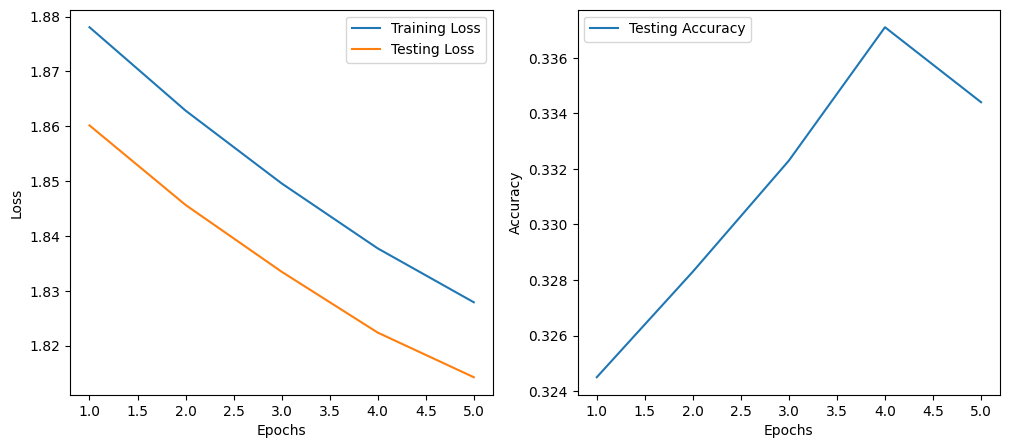

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
epochs = 5
train(model, train_loader, test_loader, optimizer, epochs)

## End of the road..

Epoch 1/5, Training Loss: 1.8279311997876744, Testing Loss: 1.813956440828098, Testing Accuracy: 0.3362
Epoch 2/5, Training Loss: 1.8193013523910875, Testing Loss: 1.8058149730816435, Testing Accuracy: 0.3405
Epoch 3/5, Training Loss: 1.8118635607467426, Testing Loss: 1.7991775689414515, Testing Accuracy: 0.3390
Epoch 4/5, Training Loss: 1.805117699174033, Testing Loss: 1.7927988980905698, Testing Accuracy: 0.3424
Epoch 5/5, Training Loss: 1.7996381379363633, Testing Loss: 1.7885543896367375, Testing Accuracy: 0.3410
Loaded the best model from epoch 4 with Testing Accuracy: 0.3424


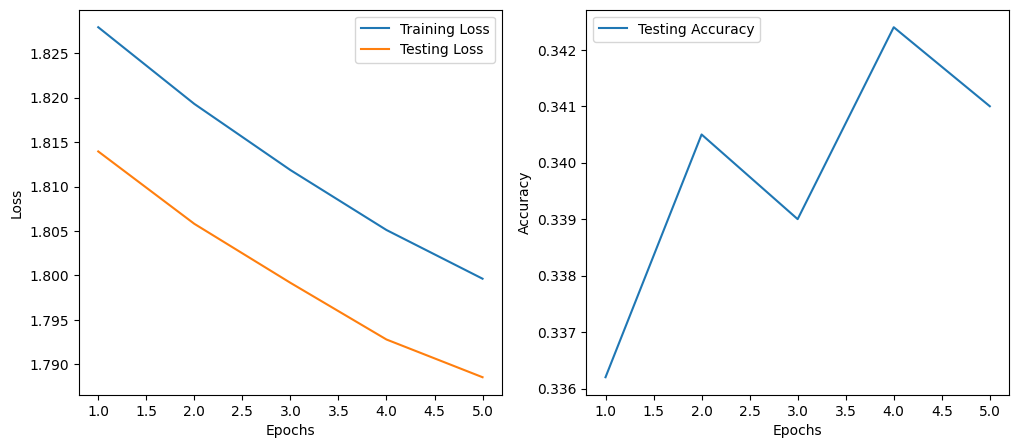

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
epochs = 5
train(model, train_loader, test_loader, optimizer, epochs)

In [ ]:
# Estimate accuracy
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        # calculate outputs by running images through the network
        outputs = model(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 34 %


## Got to about 34% Accuracy on Testing data



In [ ]:
count_trainable_parameters(model)

2538

# A Deeper Model


### Lets try to analyze each layer

In [ ]:
# CNNClassifier2: from the pytorch tutorial
class CNNClassifier2(nn.Module):
    def __init__(self):
        super().__init__()
        self.relu = nn.ReLU()
        self.conv1 = nn.Conv2d(3, 6, 5) # 109*5 parameters
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5) # (6*25+1)*16
        self.fc1 = nn.Linear(16 * 5 * 5, 120) # 400*120
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x # Note: we do not need a softmax is using CrossEntropyLoss (see optimization function)

In [ ]:
# Train
#
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Choose a model to train
model2 = CNNClassifier2()
model2.to(device)
model2.train()



CNNClassifier2(
  (relu): ReLU()
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

## Much Bigger...

How many parameters?

In [ ]:
count_trainable_parameters(model2)

62006

Epoch 1/5, Training Loss: 1.5761872489179316, Testing Loss: 1.3292708735877332, Testing Accuracy: 0.5217
Epoch 2/5, Training Loss: 1.2573220004504564, Testing Loss: 1.1888596284122894, Testing Accuracy: 0.5794
Epoch 3/5, Training Loss: 1.1285263290026977, Testing Loss: 1.1586289700989525, Testing Accuracy: 0.5819
Epoch 4/5, Training Loss: 1.047265531348633, Testing Loss: 1.066841774855178, Testing Accuracy: 0.6278
Epoch 5/5, Training Loss: 0.9802823839321857, Testing Loss: 1.1127862183811565, Testing Accuracy: 0.6099
Loaded the best model from epoch 4 with Testing Accuracy: 0.6278


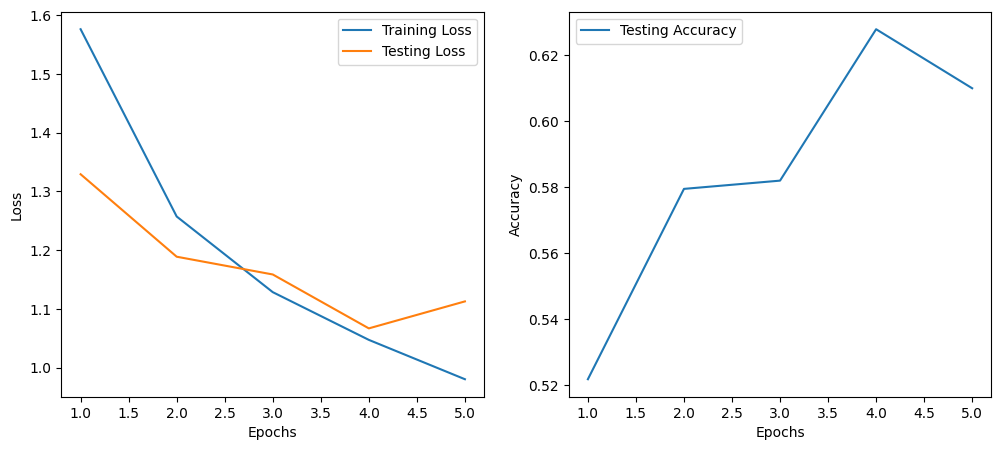

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model2.parameters(), lr=0.001, weight_decay=1e-4)
epochs = 5
train(model2, train_loader, test_loader, optimizer, epochs)

## Let's keep going

Epoch 1/5, Training Loss: 0.9001947080982242, Testing Loss: 1.0182188815963915, Testing Accuracy: 0.6451
Epoch 2/5, Training Loss: 0.8738864050869445, Testing Loss: 1.0123522813899068, Testing Accuracy: 0.6507
Epoch 3/5, Training Loss: 0.8586200219999119, Testing Loss: 1.0097836099874478, Testing Accuracy: 0.6498
Epoch 4/5, Training Loss: 0.8467225292250657, Testing Loss: 1.0004284260943295, Testing Accuracy: 0.6525
Epoch 5/5, Training Loss: 0.8348711779387579, Testing Loss: 1.000071522907708, Testing Accuracy: 0.6529
Loaded the best model from epoch 5 with Testing Accuracy: 0.6529


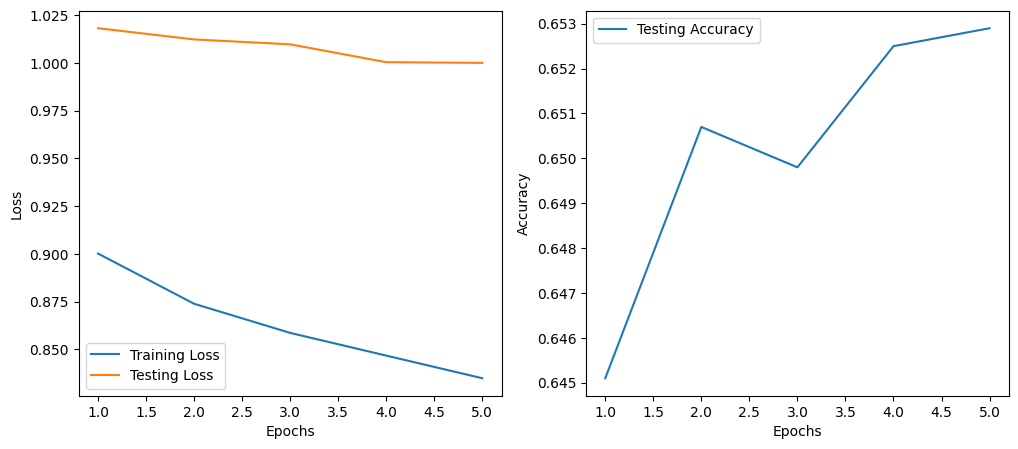

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model2.parameters(), lr=0.0001, weight_decay=1e-4)
epochs = 5
train(model2, train_loader, test_loader, optimizer, epochs)

## End of the road again?

Epoch 1/5, Training Loss: 0.8235245963090212, Testing Loss: 0.9979952909885504, Testing Accuracy: 0.6542
Epoch 2/5, Training Loss: 0.8123105213150944, Testing Loss: 0.9951744028173697, Testing Accuracy: 0.6600
Epoch 3/5, Training Loss: 0.8016051250013569, Testing Loss: 0.9966642299589639, Testing Accuracy: 0.6579
Epoch 4/5, Training Loss: 0.7924132976139957, Testing Loss: 0.9885732162113007, Testing Accuracy: 0.6581
Epoch 5/5, Training Loss: 0.7825012838161686, Testing Loss: 0.9918867461026286, Testing Accuracy: 0.6596
Loaded the best model from epoch 2 with Testing Accuracy: 0.6600


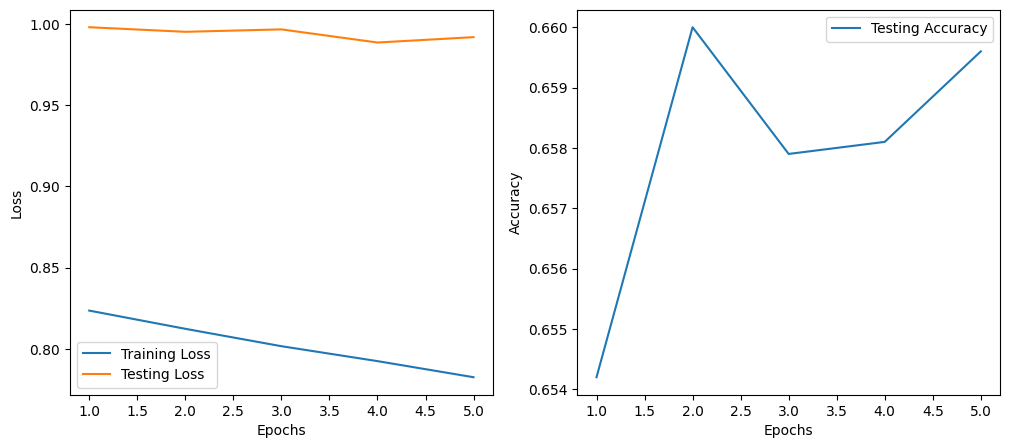

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model2.parameters(), lr=0.0001, weight_decay=1e-4)
epochs = 5
train(model2, train_loader, test_loader, optimizer, epochs)

## Much improved...

In [ ]:
# Assessing accuracy on the entire data set
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        # calculate outputs by running images through the network
        outputs = model2(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 66 %


# Let's go for a deeper yet

And use dropout and Batchnorm.

Can read more here: https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html

In [ ]:
# Define the CNN architecture
class CNNClassifierDeep(nn.Module):
    def __init__(self):
        super(CNNClassifierDeep, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.05),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.fc_layer = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(256 * 4 * 4, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = x.view(x.size(0), -1)  # Flatten the layer
        x = self.fc_layer(x)
        return x # Note: we do not need a softmax is using CrossEntropyLoss (see optimization function)

In [ ]:
model = CNNClassifier1()
model.to(device)
model.train()

CNNClassifier1(
  (conv): Conv2d(3, 16, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
  (relu): ReLU()
  (fc): Linear(in_features=16, out_features=10, bias=True)
)

In [ ]:
model3 = CNNClassifierDeep()
model3.to(device)
model3.train()

CNNClassifierDeep(
  (conv_layer): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14):

## How many parameteres?



In [ ]:
count_trainable_parameters(model3)

5853066

Epoch 1/5, Training Loss: 1.3742064022895852, Testing Loss: 1.1998753637170638, Testing Accuracy: 0.5826
Epoch 2/5, Training Loss: 0.869749652675841, Testing Loss: 0.7665318671506814, Testing Accuracy: 0.7317
Epoch 3/5, Training Loss: 0.6903192596182331, Testing Loss: 0.7645270170304722, Testing Accuracy: 0.7488
Epoch 4/5, Training Loss: 0.5883563787450564, Testing Loss: 0.6272711608642206, Testing Accuracy: 0.7891
Epoch 5/5, Training Loss: 0.5067164689750528, Testing Loss: 0.6394381895899391, Testing Accuracy: 0.7899
Loaded the best model from epoch 5 with Testing Accuracy: 0.7899


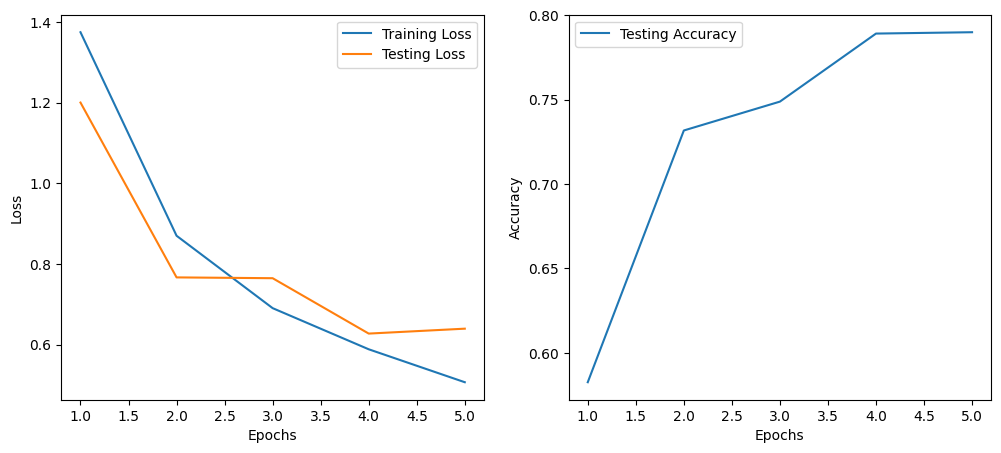

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model3.parameters(), lr=0.001, weight_decay=1e-4)
epochs = 5
train(model3, train_loader, test_loader, optimizer, epochs)

## Still improving

Epoch 1/5, Training Loss: 0.294221258237815, Testing Loss: 0.4565333263895001, Testing Accuracy: 0.8504
Epoch 2/5, Training Loss: 0.23093915572753432, Testing Loss: 0.4659250564516162, Testing Accuracy: 0.8555
Epoch 3/5, Training Loss: 0.189425903990369, Testing Loss: 0.49321583470407004, Testing Accuracy: 0.8579
Epoch 4/5, Training Loss: 0.15064196284682807, Testing Loss: 0.5096165245285811, Testing Accuracy: 0.8577
Epoch 5/5, Training Loss: 0.11317510531663476, Testing Loss: 0.5143524248498126, Testing Accuracy: 0.8606
Loaded the best model from epoch 5 with Testing Accuracy: 0.8606


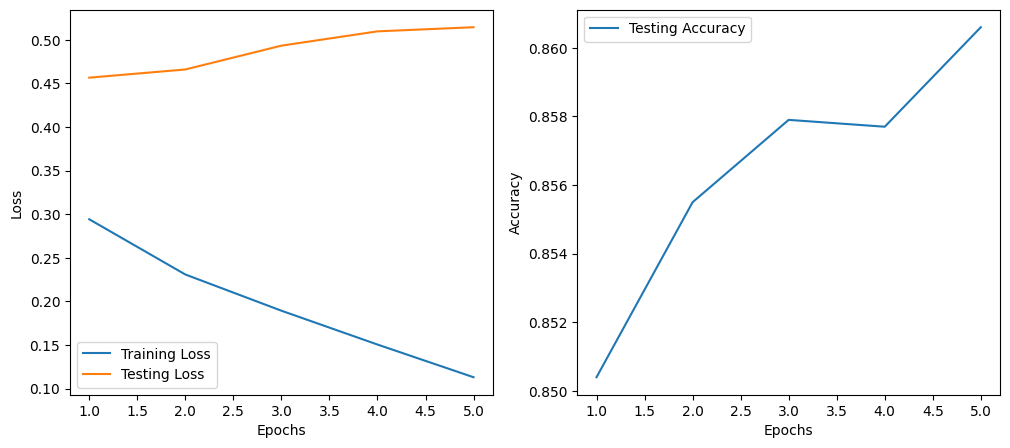

In [ ]:
torch.manual_seed(42)
optimizer = optim.Adam(model3.parameters(), lr=0.0001, weight_decay=1e-4)
epochs = 5
train(model3, train_loader, test_loader, optimizer, epochs)

Epoch 1/5, Training Loss: 0.11084864099205531, Testing Loss: 0.5477972439945505, Testing Accuracy: 0.8611
Epoch 2/5, Training Loss: 0.08934408056295595, Testing Loss: 0.5560575835882856, Testing Accuracy: 0.8606
Epoch 3/5, Training Loss: 0.0695429865736142, Testing Loss: 0.6193286364023297, Testing Accuracy: 0.8596
Epoch 4/5, Training Loss: 0.05894505166916698, Testing Loss: 0.6119222998880921, Testing Accuracy: 0.8631
Epoch 5/5, Training Loss: 0.04738219769287828, Testing Loss: 0.6228997307523085, Testing Accuracy: 0.8621
Loaded the best model from epoch 4 with Testing Accuracy: 0.8631


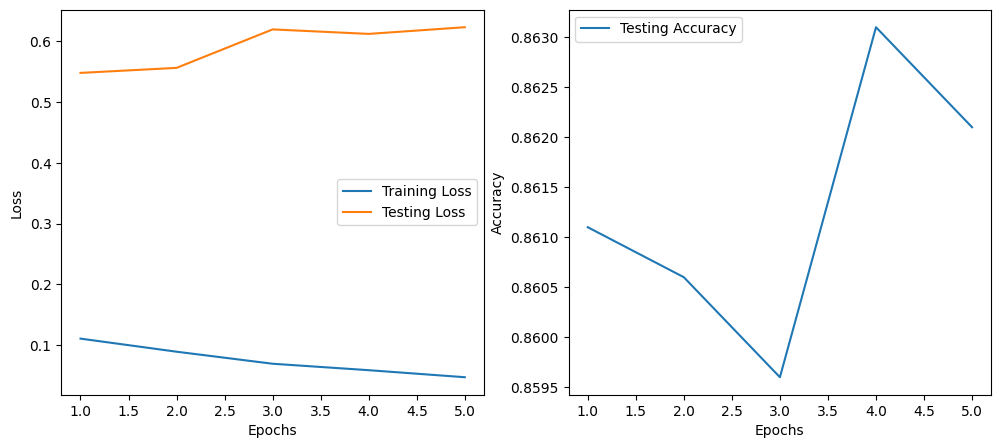

In [ ]:
optimizer = optim.Adam(model3.parameters(), lr=0.0001, weight_decay=1e-4)
epochs = 5
train(model3, train_loader, test_loader, optimizer, epochs)

### How did we do?

In [ ]:
evaluate(model3, test_loader, device)

0.8631

## What should we do now?

## Comparing Models

```
from torchsummary import summary
```
and
```
for name, layer in model2.named_modules():
    print(name,layer)
```


In [ ]:
from torchsummary import summary

summary(model,(3,32,32))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 16, 16]           2,368
              ReLU-2           [-1, 16, 16, 16]               0
            Linear-3                   [-1, 10]             170
Total params: 2,538
Trainable params: 2,538
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.06
Params size (MB): 0.01
Estimated Total Size (MB): 0.08
----------------------------------------------------------------


In [ ]:
summary(model2,(3,32,32))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 28, 28]             456
              ReLU-2            [-1, 6, 28, 28]               0
         MaxPool2d-3            [-1, 6, 14, 14]               0
            Conv2d-4           [-1, 16, 10, 10]           2,416
              ReLU-5           [-1, 16, 10, 10]               0
         MaxPool2d-6             [-1, 16, 5, 5]               0
            Linear-7                  [-1, 120]          48,120
              ReLU-8                  [-1, 120]               0
            Linear-9                   [-1, 84]          10,164
             ReLU-10                   [-1, 84]               0
           Linear-11                   [-1, 10]             850
Total params: 62,006
Trainable params: 62,006
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/ba

In [ ]:
summary(model3,(3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          18,496
       BatchNorm2d-5           [-1, 64, 32, 32]             128
              ReLU-6           [-1, 64, 32, 32]               0
         MaxPool2d-7           [-1, 64, 16, 16]               0
            Conv2d-8          [-1, 128, 16, 16]          73,856
       BatchNorm2d-9          [-1, 128, 16, 16]             256
             ReLU-10          [-1, 128, 16, 16]               0
           Conv2d-11          [-1, 128, 16, 16]         147,584
      BatchNorm2d-12          [-1, 128, 16, 16]             256
             ReLU-13          [-1, 128, 16, 16]               0
        MaxPool2d-14            [-1, 12

# Where do we go from here?